<a href="https://colab.research.google.com/github/architha-vemula/readynest-week1-superstore/blob/main/Superstore_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("/content/train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
df = df.drop_duplicates()

In [3]:
df.loc[(df["City"] == "Burlington") & (df["State"] == "Vermont"), "Postal Code"] = 5401
df["Postal Code"] = df["Postal Code"].astype("Int64")

In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

In [5]:
df["Order Year"] = df["Order Date"].dt.year

In [6]:
df["Order Month"] = df["Order Date"].dt.month

In [7]:
df["Order Month Name"] = df["Order Date"].dt.strftime("%b")

In [8]:
df["Order Weekday"] = df["Order Date"].dt.day_name()

In [9]:
df["Shipping Duration (days)"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [10]:
text_cols = df.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

In [11]:
print(df.shape)
print(df.columns.tolist())

(9800, 23)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Order Year', 'Order Month', 'Order Month Name', 'Order Weekday', 'Shipping Duration (days)']


In [12]:
df.to_csv("train_cleaned.csv", index=False)

In [13]:
from google.colab import files
files.download("train_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descriptive statistics

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train_cleaned.csv')

# Overall stats
print(df[['Sales']].describe())

# Stats by category
print(df.groupby('Category')['Sales'].agg(['sum','mean','count']))

              Sales
count   9800.000000
mean     230.769059
std      626.651875
min        0.444000
25%       17.248000
50%       54.490000
75%      210.605000
max    22638.480000
                         sum        mean  count
Category                                       
Furniture        728658.5757  350.653790   2078
Office Supplies  705422.3340  119.381001   5909
Technology       827455.8730  456.401474   1813


Univariate analysis (histogram + box plot)


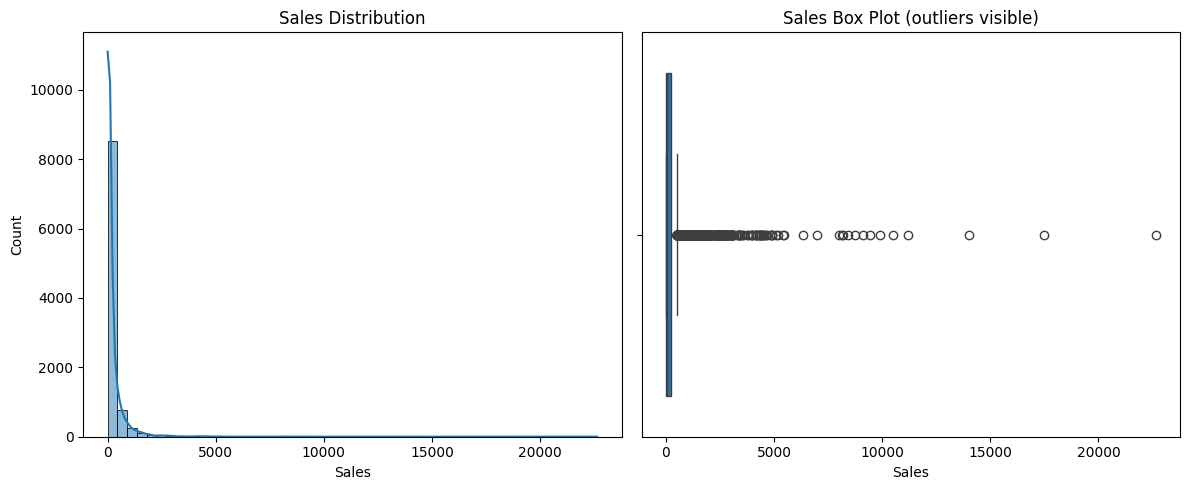

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Sales Distribution')

sns.boxplot(x=df['Sales'], ax=axes[1])
axes[1].set_title('Sales Box Plot (outliers visible)')
plt.tight_layout()
plt.show()

Bivariate analysis (scatter + correlation heatmap)

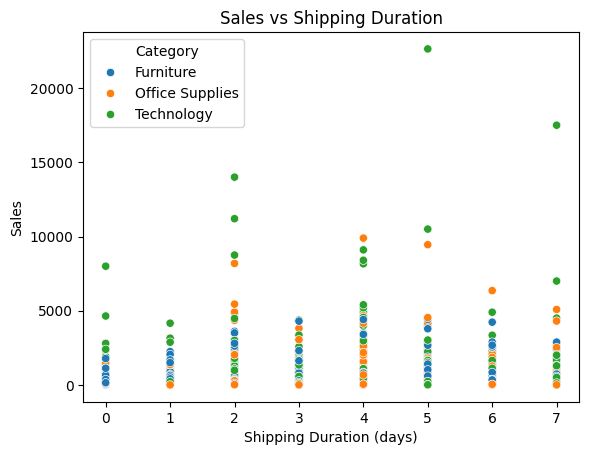

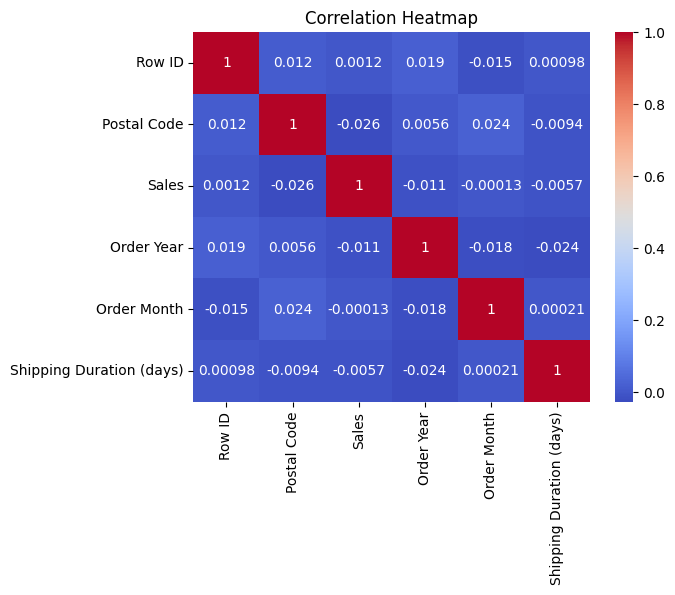

In [16]:
# Scatter: Sales vs Shipping Duration
sns.scatterplot(data=df, x='Shipping Duration (days)', y='Sales', hue='Category')
plt.title('Sales vs Shipping Duration')
plt.show()

# Correlation heatmap (numeric columns only)
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

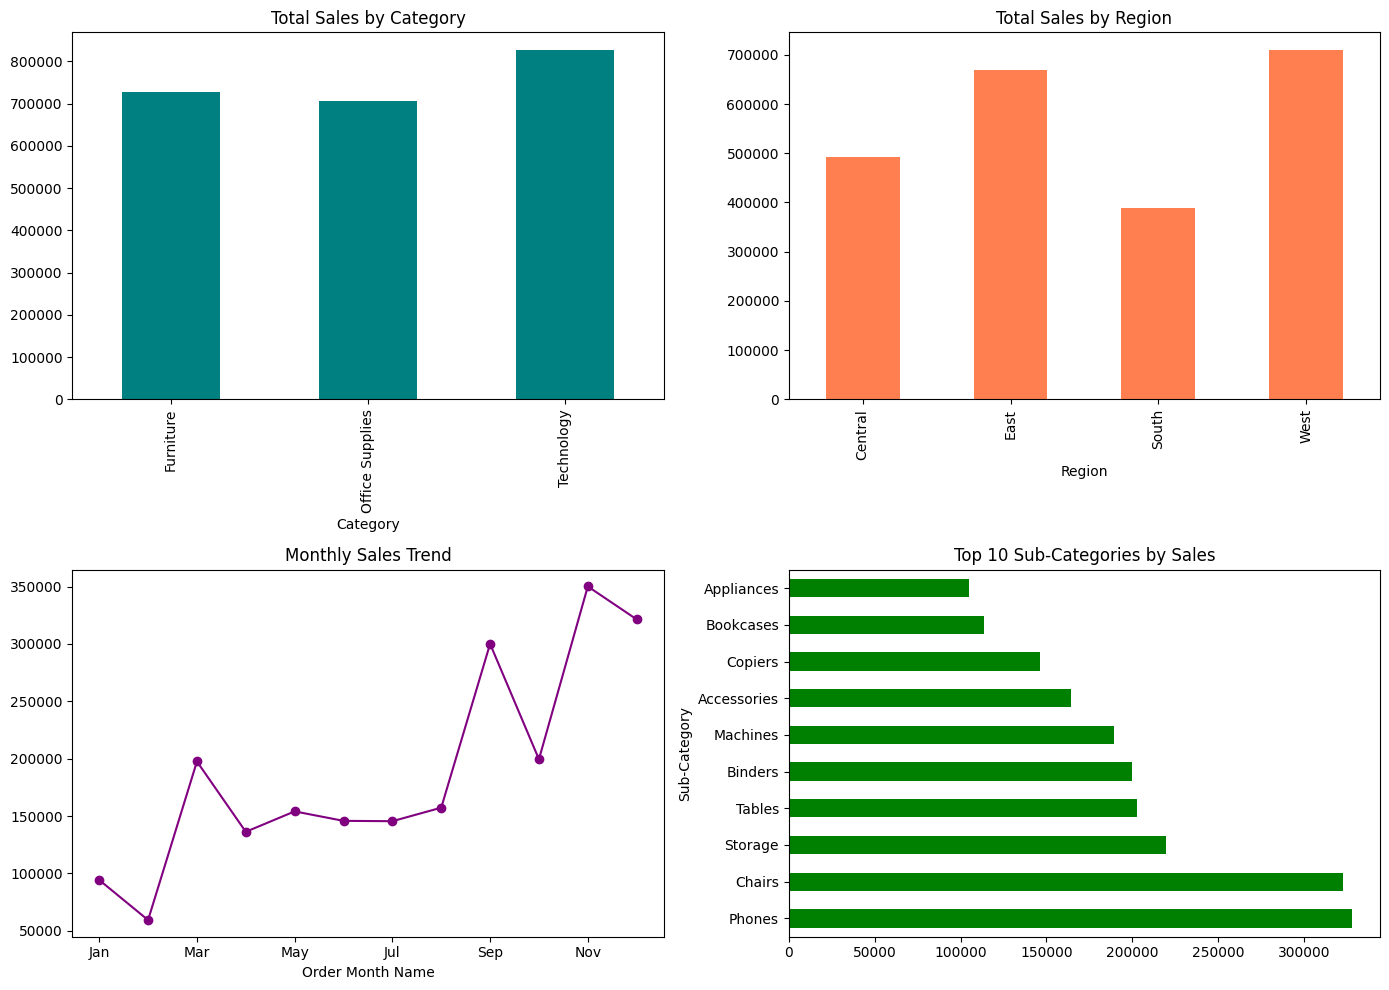

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Sales by Category
df.groupby('Category')['Sales'].sum().plot(kind='bar', ax=axes[0,0], color='teal')
axes[0,0].set_title('Total Sales by Category')

# Sales by Region
df.groupby('Region')['Sales'].sum().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Total Sales by Region')

# Monthly sales trend
df.groupby('Order Month Name')['Sales'].sum().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
).plot(kind='line', marker='o', ax=axes[1,0], color='purple')
axes[1,0].set_title('Monthly Sales Trend')

# Top 10 Sub-Categories
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10).plot(
    kind='barh', ax=axes[1,1], color='green')
axes[1,1].set_title('Top 10 Sub-Categories by Sales')

plt.tight_layout()
plt.show()

Key Insights

Technology has the highest total sales despite the fewest orders, because each Tech purchase averages ₹456 vs ₹119 for Office Supplies — high-value, low-frequency buyers.

West has the highest sales among all regions, while South has the lowest — possibly due to fewer stores or customers in that area.

Sales are lower in the early months (Jan-Feb) and rise sharply by Sep-Nov, likely due to year-end and holiday shopping.

Phones and Chairs are the top-selling sub-categories, showing that high-ticket items drive most of the revenue.